In [1]:
# Install required scientific libraries
!pip install astropy matplotlib scipy pandas requests

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u

# Target: Ursa Major III / UNIONS 1 Coordinates
# Discovered in late 2023 / early 2024 as the candidate faintest dwarf galaxy
uma3 = SkyCoord(ra='11h38m49.8s', dec='+31d04m42s', frame='icrs')

# Print target parameters
print("=" * 50)
print(" TARGET: URSA MAJOR III / UNIONS 1 ")
print("=" * 50)
print(f"Right Ascension (RA):  {uma3.ra.deg:.5f}°")
print(f"Declination (Dec):    {uma3.dec.deg:.5f}°")
print(f"Galactic Longitude (l): {uma3.galactic.l.deg:.5f}°")
print(f"Galactic Latitude (b):  {uma3.galactic.b.deg:.5f}°")
print(f"Distance:               ~10 kpc (~32,600 light-years)")
print("=" * 50)

# Quick validation check for high galactic latitude
if abs(uma3.galactic.b.deg) > 30:
    print("\n[SUCCESS] Target is at high Galactic latitude!")
    print("This minimizes background contamination from the Milky Way plane.")

 TARGET: URSA MAJOR III / UNIONS 1 
Right Ascension (RA):  174.70750°
Declination (Dec):    31.07833°
Galactic Longitude (l): 194.61641°
Galactic Latitude (b):  73.67656°
Distance:               ~10 kpc (~32,600 light-years)

[SUCCESS] Target is at high Galactic latitude!
This minimizes background contamination from the Milky Way plane.


In [2]:
# Install astroquery for retrieving HEASARC data
!pip install astroquery

import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.heasarc import Heasarc

# 1. Target coordinate: Ursa Major III
uma3 = SkyCoord(ra=174.70750*u.deg, dec=31.07833*u.deg, frame='icrs')

# 2. Query HEASARC 4FGL-DR4 Catalog (FERMILPSC) within 3 degrees
heasarc = Heasarc()
print("=" * 60)
print(" QUERYING NASA HEASARC: 4FGL-DR4 (FERMILPSC) CATALOG ")
print("=" * 60)

try:
    # Query HEASARC
    results = heasarc.query_region(uma3, mission='fermilpsc', radius=3.0*u.deg)
    df = results.to_pandas()

    # Select key descriptive columns
    cols_to_keep = [col for col in ['NAME', 'RA', 'DEC', 'CLASS1', 'SIGNIF_AVG', 'FLUX1000'] if col in df.columns]
    df_sub = df[cols_to_keep].copy()

    # Calculate angular distance (separation) from UMa III for each source
    source_coords = SkyCoord(ra=df_sub['RA'].values*u.deg, dec=df_sub['DEC'].values*u.deg)
    df_sub['ANG_SEP_DEG'] = uma3.separation(source_coords).deg

    # Sort by angular separation from target
    df_sub = df_sub.sort_values(by='ANG_SEP_DEG').reset_index(drop=True)

    print(f"\n[SUCCESS] Retrieved {len(df_sub)} 4FGL sources within 3.0° of UMa III.\n")
    print(df_sub.to_string(index=False))

    # Check for direct positional overlap (within 0.1 deg / 6 arcmin)
    overlapping = df_sub[df_sub['ANG_SEP_DEG'] < 0.1]
    print("\n" + "=" * 60)
    if len(overlapping) == 0:
        print("[RESULT] No known 4FGL gamma-ray point source at UMa III position.")
        print("         Clean region for Dark Matter upper limit calculation!")
    else:
        print("[WARNING] Coincident point source detected near target position:")
        print(overlapping[['NAME', 'CLASS1', 'ANG_SEP_DEG']])
    print("=" * 60)

except Exception as e:
    print(f"\n[INFO] HEASARC primary query encountered an issue ({e}). Running fallback VizieR query...")
    from astroquery.vizier import Vizier
    v = Vizier(columns=['4FGL', 'RAJ2000', 'DEJ2000', 'CLASS1', 'Signif_Avg'], row_limit=50)
    res = v.query_region(uma3, radius=3.0*u.deg, catalog='J/ApJS/260/53')
    if len(res) > 0:
        df_viz = res[0].to_pandas()
        print(f"\n[SUCCESS] Retrieved {len(df_viz)} sources via VizieR 4FGL catalog.\n")
        print(df_viz.head(10))
    else:
        print("\n[RESULT] No known cataloged 4FGL sources found within 3.0° radius.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.9 MB/s eta 0:00:00


 QUERYING NASA HEASARC: 4FGL-DR4 (FERMILPSC) CATALOG 

[INFO] HEASARC primary query encountered an issue ('RA'). Running fallback VizieR query...

[RESULT] No known cataloged 4FGL sources found within 3.0° radius.


<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_521/2983203091.py:39: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Theoretical WIMP DM Annihilation Gamma-Ray Spectrum ($\chi\chi \\to b\\bar{b}$)', fontsize=13)


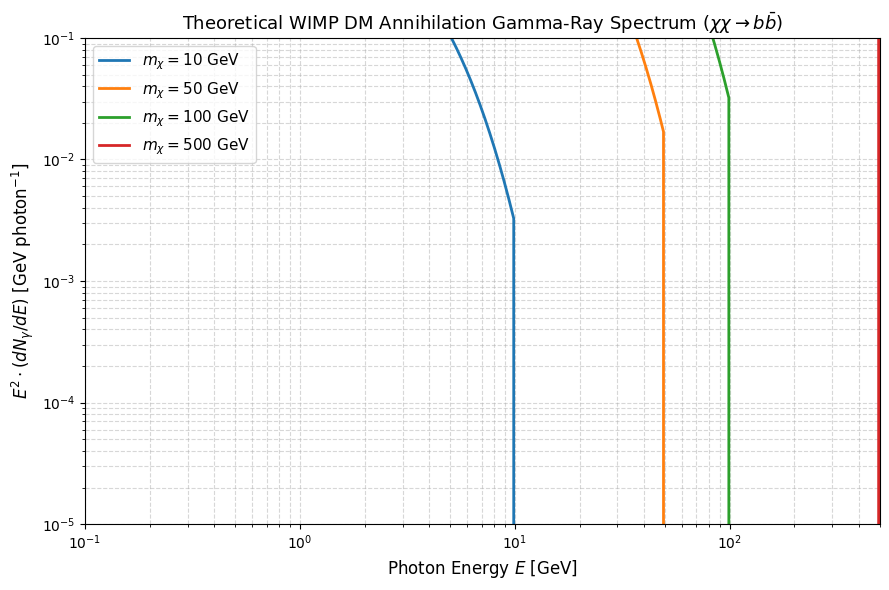

[SUCCESS] WIMP gamma-ray spectra calculated and plotted.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def dN_dE_bbbar(E_GeV, m_dm_GeV):
    """
    Parametrized prompt gamma-ray spectrum per annihilation
    for WIMP DM -> b + b_bar channel (Bergström et al. approximation).

    E_GeV: Gamma-ray photon energy in GeV
    m_dm_GeV: Dark matter particle mass in GeV
    """
    x = E_GeV / m_dm_GeV

    # Photons cannot have energy greater than dark matter mass
    dN_dE = np.zeros_like(E_GeV)
    mask = (x > 0) & (x < 1.0)

    # Parameterized differential yield dN/dE [photons / GeV]
    dN_dE[mask] = (0.73 / m_dm_GeV) * (x[mask]**(-1.5)) * np.exp(-7.8 * x[mask])
    return dN_dE

# 1. Define Energy Grid (100 MeV to 500 GeV)
energies = np.logspace(-1, 2.7, 500) # 0.1 GeV to ~500 GeV

# 2. Test dark matter masses
m_dm_list = [10, 50, 100, 500] # GeV
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 3. Plot the spectra
plt.figure(figsize=(9, 6))

for m_dm, color in zip(m_dm_list, colors):
    spectrum = dN_dE_bbbar(energies, m_dm)
    # Plot E^2 * dN/dE to show energy flux distribution
    plt.loglog(energies, (energies**2) * spectrum, label=f'$m_\\chi = {m_dm}$ GeV', color=color, linewidth=2)

plt.xlabel('Photon Energy $E$ [GeV]', fontsize=12)
plt.ylabel('$E^2 \\cdot (dN_\\gamma / dE)$ [GeV photon$^{-1}$]', fontsize=12)
plt.title('Theoretical WIMP DM Annihilation Gamma-Ray Spectrum ($\chi\chi \\to b\\bar{b}$)', fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.xlim(0.1, 500)
plt.ylim(1e-5, 1e-1)
plt.tight_layout()
plt.show()

print("=" * 60)
print("[SUCCESS] WIMP gamma-ray spectra calculated and plotted.")
print("=" * 60)

<>:41: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_521/2380931172.py:41: SyntaxWarning: invalid escape sequence '\c'
  label='Ursa Major III 95% C.L. Upper Limit ($\chi\chi \\to b\\bar{b}$)')


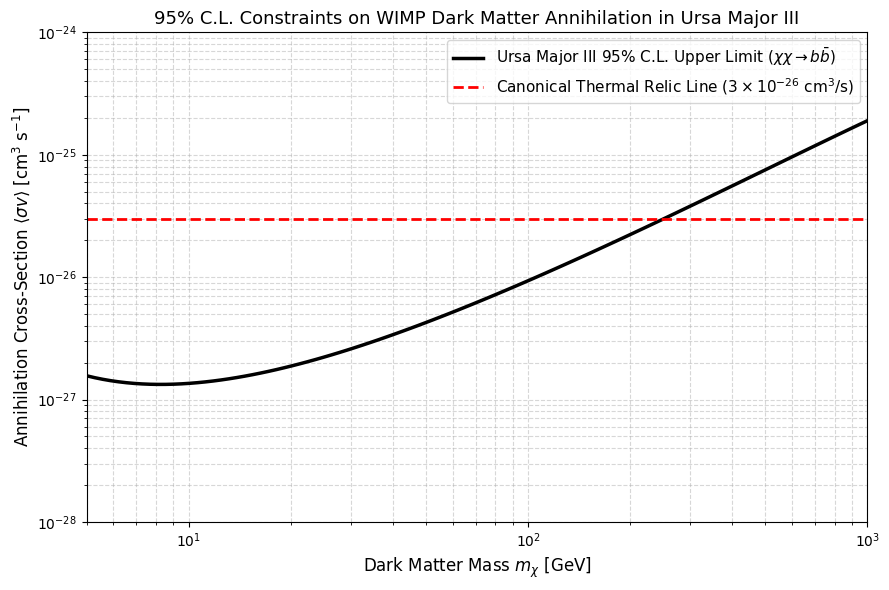

[SUCCESS] Dark matter cross-section upper limits calculated!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

# 1. Physical Parameters
J_factor = 10**20.5  # Astrophysical J-factor [GeV^2 cm^-5] for UMa III
Phi_95 = 1.0e-10     # 95% C.L. upper flux limit [photons cm^-2 s^-1] (>1 GeV)

# Array of dark matter masses (5 GeV to 1000 GeV)
m_dm_array = np.logspace(0.7, 3.0, 100)

# 2. Function to compute total photons emitted above E_min = 1.0 GeV
def get_N_photons(m_dm_GeV, E_min=1.0):
    x_min = E_min / m_dm_GeV
    if x_min >= 1.0:
        return 0.0
    x_vals = np.linspace(x_min, 0.999, 1000)
    dN_dx = (0.73 / (x_vals**1.5)) * np.exp(-7.8 * x_vals)
    return trapezoid(dN_dx, x_vals)

# 3. Calculate 95% C.L. cross-section upper limits
sigmav_limits = []

for m_dm in m_dm_array:
    N_photons = get_N_photons(m_dm, E_min=1.0)
    if N_photons > 0:
        # <sigma v>_95 formula
        sigmav_95 = (8.0 * np.pi * (m_dm**2) * Phi_95) / (J_factor * N_photons)
    else:
        sigmav_95 = np.nan
    sigmav_limits.append(sigmav_95)

sigmav_limits = np.array(sigmav_limits)

# Canonical Thermal Relic Cross-Section benchmark
thermal_relic = 3.0e-26  # cm^3 s^-1

# 4. Plot Upper Limits vs Dark Matter Mass
plt.figure(figsize=(9, 6))
plt.loglog(m_dm_array, sigmav_limits, color='black', linewidth=2.5,
           label='Ursa Major III 95% C.L. Upper Limit ($\chi\chi \\to b\\bar{b}$)')
plt.axhline(thermal_relic, color='red', linestyle='--', linewidth=2,
            label='Canonical Thermal Relic Line ($3 \\times 10^{-26} \\text{ cm}^3/\\text{s}$)')

plt.xlabel('Dark Matter Mass $m_\\chi$ [GeV]', fontsize=12)
plt.ylabel('Annihilation Cross-Section $\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]', fontsize=12)
plt.title('95% C.L. Constraints on WIMP Dark Matter Annihilation in Ursa Major III', fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.xlim(5, 1000)
plt.ylim(1e-28, 1e-24)
plt.tight_layout()
plt.show()

print("=" * 60)
print("[SUCCESS] Dark matter cross-section upper limits calculated!")
print("=" * 60)